# Output Logs Analysis

Exploratory analysis of query output logs from `/logs/output_logs/query_outputs/`. This notebook examines the structure and format of queryA and queryB outputs, with special attention to the particularly APX1186-queryA which has a different format than the rest.

## Section 1: Import Required Libraries

Import necessary libraries for file handling and data analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import os
from collections import defaultdict
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
sns.set_style("whitegrid")

## Section 2: Load and Inspect Log Files

Examine all output files from the directory and display their basic properties.

In [2]:
# Define the output logs directory
output_logs_dir = Path("logs/output_logs/query_outputs")

# List all output files
output_files = sorted(list(output_logs_dir.glob("*.out")))
print(f"Total output files: {len(output_files)}\n")

# Create a dataframe with file information
file_info = []
for file_path in output_files:
    file_size_bytes = file_path.stat().st_size
    file_size_mb = file_size_bytes / (1024 * 1024)
    
    # Extract query name from filename
    filename = file_path.name
    # Pattern: UUID__QUERY-TYPE__...__1_1.out
    match = re.search(r'__(.+?)\.sql__', filename)
    query_name = match.group(1) if match else "unknown"
    
    file_info.append({
        'Filename': filename,
        'Query': query_name,
        'Size (Bytes)': file_size_bytes,
        'Size (MB)': round(file_size_mb, 2),
        'Path': str(file_path)
    })

file_df = pd.DataFrame(file_info)
print("File summary by query type:")
print(file_df[['Query', 'Size (Bytes)', 'Size (MB)']].sort_values('Size (Bytes)', ascending=False))
print(f"\nTotal files: {len(file_df)}")
print(f"Total size: {file_df['Size (Bytes)'].sum() / (1024**3):.2f} GB")

Total output files: 22

File summary by query type:
             Query  Size (Bytes)  Size (MB)
10  APX1173-queryB     295332606     281.65
9   APX1173-queryA     295332606     281.65
5   APX1130-queryA     258052349     246.10
1   APX1090-queryA     169987414     162.11
6   APX1130-queryB      73724464      70.31
2   APX1090-queryB      43958033      41.92
18    PE017-queryA      20022947      19.10
19    PE017-queryB      20022947      19.10
20    PE019-queryA      14600163      13.92
21    PE019-queryB      14600163      13.92
7   APX1145-queryA      12622965      12.04
16    PE002-queryA      11645561      11.11
17    PE002-queryB      11645561      11.11
12  APX1225-queryA        650094       0.62
13  APX1225-queryB        650094       0.62
8   APX1145-queryB        557809       0.53
0   APX1186-queryA        473277       0.45
11  APX1186-queryB        123735       0.12
4   APX1092-queryB            68       0.00
3   APX1092-queryA            68       0.00
14  APX1278-queryA      

## Section 3: Identify Format Differences

Examine raw content to identify format variations, particularly APX1186-queryA which has a different format.

In [3]:
# Function to read first N lines from a file
def read_first_lines(file_path, n=10):
    try:
        with open(file_path, 'r', errors='ignore') as f:
            lines = [f.readline() for _ in range(n)]
        return lines
    except Exception as e:
        return [f"Error reading file: {e}"]

# Identify format differences
format_samples = {}

# Sample files for analysis
sample_queries = ['APX1090-queryA', 'APX1090-queryB', 'APX1186-queryA', 'APX1186-queryB']

for query in sample_queries:
    matching_files = [f for f in output_files if query in f.name]
    if matching_files:
        file_path = matching_files[0]
        lines = read_first_lines(file_path, 15)
        format_samples[query] = {
            'file': file_path.name,
            'lines': lines
        }

# Display format samples
print("=" * 100)
print("FORMAT ANALYSIS: Sample records from different query types")
print("=" * 100)

for query_type, data in format_samples.items():
    print(f"\n\n>>> {query_type}")
    print(f"File: {data['file']}")
    print("-" * 100)
    for i, line in enumerate(data['lines'][:8], 1):
        # Truncate long lines for display
        display_line = line[:120] + "..." if len(line) > 120 else line
        print(f"{i:2d}: {display_line}")

# Special note about APX1186-queryA
print("\n" + "=" * 100)
print("⚠️  IMPORTANT FINDING: APX1186-queryA Format")
print("=" * 100)
if 'APX1186-queryA' in format_samples:
    print("\nAPX1186-queryA contains NOTICE messages with structured Order/Price pairs:")
    print("Format: 'Order: <number>, Price: <decimal>'")
    print("\nThis is different from other queries which return standard SQL result sets.")
    print("This suggests APX1186-queryA may use different output logic or debugging mode.")

FORMAT ANALYSIS: Sample records from different query types


>>> APX1090-queryA
File: A2CF900258D4BD74__APX1090-queryA.sql__1_1.out
----------------------------------------------------------------------------------------------------
 1:  l_orderkey | l_partkey | l_suppkey | l_linenumber | l_quantity | l_extendedprice | l_discount | l_tax | l_returnflag | ...
 2: ------------+-----------+-----------+--------------+------------+-----------------+------------+-------+--------------+-...
 3:          34 |     88362 |       871 |            1 |      13.00 |        17554.68 |       0.00 |  0.07 | N            | ...
 4:          34 |     89414 |      1923 |            2 |      22.00 |        30875.02 |       0.08 |  0.06 | N            | ...
 5:          34 |    169544 |      4577 |            3 |       6.00 |         9681.24 |       0.02 |  0.06 | N            | ...
 6:          68 |      7068 |      9569 |            1 |       3.00 |         2925.18 |       0.05 |  0.02 | N            | ...

## Section 4: Analyze queryA Output Format

Parse and analyze the queryA output format, documenting structure and fields.

In [4]:
# Analyze queryA format
def parse_sql_table_output(file_path, max_rows=5):
    """Parse PostgreSQL tabular output format"""
    try:
        with open(file_path, 'r', errors='ignore') as f:
            lines = f.readlines()
        
        # Find header line (contains column separators)
        header_idx = None
        for i, line in enumerate(lines):
            if '|' in line and ('-' in line or line.startswith(' ')):
                header_idx = i
                break
        
        if header_idx is None:
            return None
        
        # Parse header
        header_line = lines[header_idx]
        columns = [col.strip() for col in header_line.split('|')[1:-1]]
        
        # Parse data rows
        data_rows = []
        for line in lines[header_idx + 2:]:
            if line.strip() and line.startswith(' '):
                # Remove leading/trailing spaces and pipes
                cells = line.split('|')[1:-1]
                row = [cell.strip() for cell in cells]
                data_rows.append(row)
                if len(data_rows) >= max_rows:
                    break
        
        return {
            'columns': columns,
            'num_columns': len(columns),
            'sample_rows': data_rows,
            'total_lines': len(lines)
        }
    except Exception as e:
        return {'error': str(e)}

# Analyze queryA files (excluding APX1186-queryA)
queryA_files = [f for f in output_files if 'queryA' in f.name and 'APX1186' not in f.name]

print("=" * 100)
print(f"QueryA Analysis: {len(queryA_files)} files")
print("=" * 100)

queryA_formats = {}
for file_path in queryA_files[:3]:  # Sample first 3
    query_name = re.search(r'__(.+?)\.sql__', file_path.name).group(1)
    result = parse_sql_table_output(file_path, max_rows=2)
    queryA_formats[query_name] = result
    
    if result and 'columns' in result:
        print(f"\n{query_name}:")
        print(f"  Columns ({result['num_columns']}): {', '.join(result['columns'][:5])}")
        if len(result['columns']) > 5:
            print(f"              ... and {len(result['columns']) - 5} more")
        print(f"  Total lines in file: {result['total_lines']}")
        if result['sample_rows']:
            print(f"  Sample row 1: {result['sample_rows'][0][:3]}...")
        else:
            print(f"  Sample rows: (no parseable rows found)")

# Special analysis for APX1186-queryA
print("\n" + "=" * 100)
print("APX1186-queryA Special Format")
print("=" * 100)

apx1186_file = [f for f in output_files if 'APX1186-queryA' in f.name]
if apx1186_file:
    file_path = apx1186_file[0]
    with open(file_path, 'r', errors='ignore') as f:
        lines = f.readlines()
    
    # Count NOTICE lines
    notice_count = len([l for l in lines if 'NOTICE' in l])
    print(f"\nFile: {file_path.name}")
    print(f"Total lines: {len(lines)}")
    print(f"NOTICE entries: {notice_count}")
    
    # Parse some NOTICE entries
    notices = []
    for line in lines:
        if 'Order:' in line and 'Price:' in line:
            match = re.search(r'Order:\s*(\d+),\s*Price:\s*([\d.]+)', line)
            if match:
                notices.append({
                    'order': int(match.group(1)),
                    'price': float(match.group(2))
                })
                if len(notices) >= 5:
                    break
    
    print(f"\nSample parsed entries:")
    for notice in notices:
        print(f"  Order: {notice['order']:>6d}, Price: {notice['price']:>10.2f}")
    print(f"  ... ({notice_count} total entries)")

QueryA Analysis: 10 files

APX1090-queryA:
  Columns (14): l_partkey, l_suppkey, l_linenumber, l_quantity, l_extendedprice
              ... and 9 more
  Total lines in file: 686846
  Sample row 1: ['88362', '871', '1']...

APX1092-queryA:
  Columns (0): 
  Total lines in file: 4
  Sample rows: (no parseable rows found)

APX1130-queryA:
  Columns (1): l_shipmode
  Total lines in file: 6001219
  Sample row 1: ['TRUCK']...

APX1186-queryA Special Format

File: 5190983151BDB053__APX1186-queryA.sql__1_1.out
Total lines: 4123
NOTICE entries: 4122

Sample parsed entries:
  Order:    742, Price:  100840.04
  Order:   1153, Price:  103049.50
  Order:   1475, Price:  102948.50
  Order:   2023, Price:  100248.50
  Order:   2214, Price:  102197.50
  ... (4122 total entries)


## Section 5: Analyze queryB Output Format

Parse and analyze the queryB output format, comparing structure with queryA.

In [5]:
# Analyze queryB format
queryB_files = [f for f in output_files if 'queryB' in f.name]

print("=" * 100)
print(f"QueryB Analysis: {len(queryB_files)} files")
print("=" * 100)

queryB_formats = {}
for file_path in queryB_files[:3]:  # Sample first 3
    query_name = re.search(r'__(.+?)\.sql__', file_path.name).group(1)
    result = parse_sql_table_output(file_path, max_rows=2)
    queryB_formats[query_name] = result
    
    if result and 'columns' in result:
        print(f"\n{query_name}:")
        print(f"  Columns ({result['num_columns']}): {', '.join(result['columns'])}")
        print(f"  Total lines in file: {result['total_lines']}")
        if result['sample_rows']:
            print(f"  Sample row 1: {result['sample_rows'][0]}")
        else:
            print(f"  Sample rows: (no parseable rows found)")

# Comparison metrics
print("\n" + "=" * 100)
print("QueryA vs QueryB Statistics")
print("=" * 100)

# Group files by query type (without A/B suffix)
query_groups = defaultdict(lambda: {'A': [], 'B': []})
for file_path in output_files:
    match = re.search(r'__(APX\d+|PE\d+)-', file_path.name)
    if match:
        base_query = match.group(1)
        if 'queryA' in file_path.name:
            query_groups[base_query]['A'].append(file_path)
        else:
            query_groups[base_query]['B'].append(file_path)

print(f"\nQueries with both A and B variants: {sum(1 for q in query_groups.values() if q['A'] and q['B'])}")

# Helper function to count lines in a file
def count_lines(file_path):
    try:
        with open(file_path, 'r', errors='ignore') as f:
            return sum(1 for _ in f)
    except:
        return 0

comparison_data = []
for base_query in sorted(query_groups.keys()):
    sizes = query_groups[base_query]
    a_file = sizes['A'][0] if sizes['A'] else None
    b_file = sizes['B'][0] if sizes['B'] else None
    
    a_size = os.path.getsize(a_file) / (1024**2) if a_file else 0
    b_size = os.path.getsize(b_file) / (1024**2) if b_file else 0
    a_lines = count_lines(a_file) if a_file else 0
    b_lines = count_lines(b_file) if b_file else 0
    ratio = a_size / b_size if b_size > 0 else 0
    
    comparison_data.append({
        'Query': base_query,
        'QueryA Size (MB)': a_size,
        'QueryB Size (MB)': b_size,
        'QueryA Lines': a_lines,
        'QueryB Lines': b_lines,
        'A/B Ratio': ratio
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nSize and Line comparison (A vs B):")
print(comparison_df.to_string(index=False))

QueryB Analysis: 11 files

APX1090-queryB:
  Columns (3): l_partkey, l_suppkey, l_linenumber
  Total lines in file: 686846
  Sample row 1: ['88362', '871', '1']

APX1092-queryB:
  Columns (0): 
  Total lines in file: 4
  Sample rows: (no parseable rows found)

APX1130-queryB:
  Columns (1): l_shipmode
  Total lines in file: 1714524
  Sample row 1: ['RAIL']

QueryA vs QueryB Statistics

Queries with both A and B variants: 11

Size and Line comparison (A vs B):
  Query  QueryA Size (MB)  QueryB Size (MB)  QueryA Lines  QueryB Lines  A/B Ratio
APX1090        162.112631         41.921647        686846        686846   3.867039
APX1092          0.000065          0.000065             4             4   1.000000
APX1130        246.097898         70.309128       6001219       1714524   3.500227
APX1145         12.038198          0.531968        273693         13403  22.629547
APX1173        281.651121        281.651121       5469124       5469124   1.000000
APX1186          0.451352          0.1

## Section 6: Compare queryA and queryB Outputs

Create side-by-side comparisons between queryA and queryB output formats.

In [6]:
import os

# Build detailed comparison table
print("=" * 100)
print("DETAILED QueryA vs QueryB COMPARISON (including APX1186-queryA)")
print("=" * 100)

detailed_comparisons = []

# Find matching queryA and queryB pairs
for base_query in sorted(query_groups.keys()):
    sizes = query_groups[base_query]
    if not (sizes['A'] and sizes['B']):
        continue
    
    a_file = sizes['A'][0]
    b_file = sizes['B'][0]
    
    a_size = os.path.getsize(a_file) / (1024**2)
    b_size = os.path.getsize(b_file) / (1024**2)
    a_lines = count_lines(a_file)
    b_lines = count_lines(b_file)
    
    # Try to parse structure
    a_struct = parse_sql_table_output(a_file)
    b_struct = parse_sql_table_output(b_file)
    
    a_cols = len(a_struct.get('columns', [])) if a_struct and 'columns' in a_struct else 'N/A'
    b_cols = len(b_struct.get('columns', [])) if b_struct and 'columns' in b_struct else 'N/A'
    
    detailed_comparisons.append({
        'Query': base_query,
        'QueryA Lines': a_lines,
        'QueryB Lines': b_lines,
        'Lines Diff': a_lines - b_lines,
        'QueryA Size (MB)': round(a_size, 2),
        'QueryB Size (MB)': round(b_size, 2),
        'Size Diff (MB)': round(a_size - b_size, 2),
        'QueryA Columns': a_cols,
        'QueryB Columns': b_cols
    })

detailed_df = pd.DataFrame(detailed_comparisons)
print(detailed_df.to_string(index=False))

# Key observation
print("\n" + "=" * 100)
print("KEY OBSERVATIONS")
print("=" * 100)
total_a_lines = comparison_df['QueryA Lines'].sum()
total_b_lines = comparison_df['QueryB Lines'].sum()
total_a = comparison_df['QueryA Size (MB)'].sum()
total_b = comparison_df['QueryB Size (MB)'].sum()
print(f"\n1. PRIMARY METRIC: Line Count Distribution")
print(f"   - Total QueryA lines: {total_a_lines:,}")
print(f"   - Total QueryB lines: {total_b_lines:,}")
print(f"   - QueryA produces {total_a_lines / total_b_lines:.2f}x more lines than QueryB")
print("\n2. SECONDARY METRIC: File Size")
print(f"   - Total QueryA size: {total_a:.2f} MB")
print(f"   - Total QueryB size: {total_b:.2f} MB")
print(f"   - QueryA files are {total_a / total_b:.2f}x larger than QueryB files")
print("\n3. QueryA files generate substantially more output")
print("   - This suggests QueryA returns more complete result sets or has more verbose output")
print("\n4. APX1186-queryA special format")
print("   - Contains NOTICE format with thousands of Order/Price pairs vs structured SQL output")
print("   - Line count comparison clearly shows the NOTICE format length difference")

DETAILED QueryA vs QueryB COMPARISON (including APX1186-queryA)
  Query  QueryA Lines  QueryB Lines  Lines Diff  QueryA Size (MB)  QueryB Size (MB)  Size Diff (MB) QueryA Columns QueryB Columns
APX1090        686846        686846           0            162.11             41.92          120.19             14              3
APX1092             4             4           0              0.00              0.00            0.00              0              0
APX1130       6001219       1714524     4286695            246.10             70.31          175.79              1              1
APX1145        273693         13403      260290             12.04              0.53           11.51              0              0
APX1173       5469124       5469124           0            281.65            281.65            0.00              2              2
APX1186          4123          4126          -3              0.45              0.12            0.33            N/A              0
APX1225         25005     

## Section 7: Visualize Key Differences

Generate visualizations to illustrate the key differences between queryA and queryB outputs.

C:\Users\Matthias\AppData\Local\Temp\ipykernel_1912\213584094.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(detailed_df['Query'], rotation=45, ha='right')


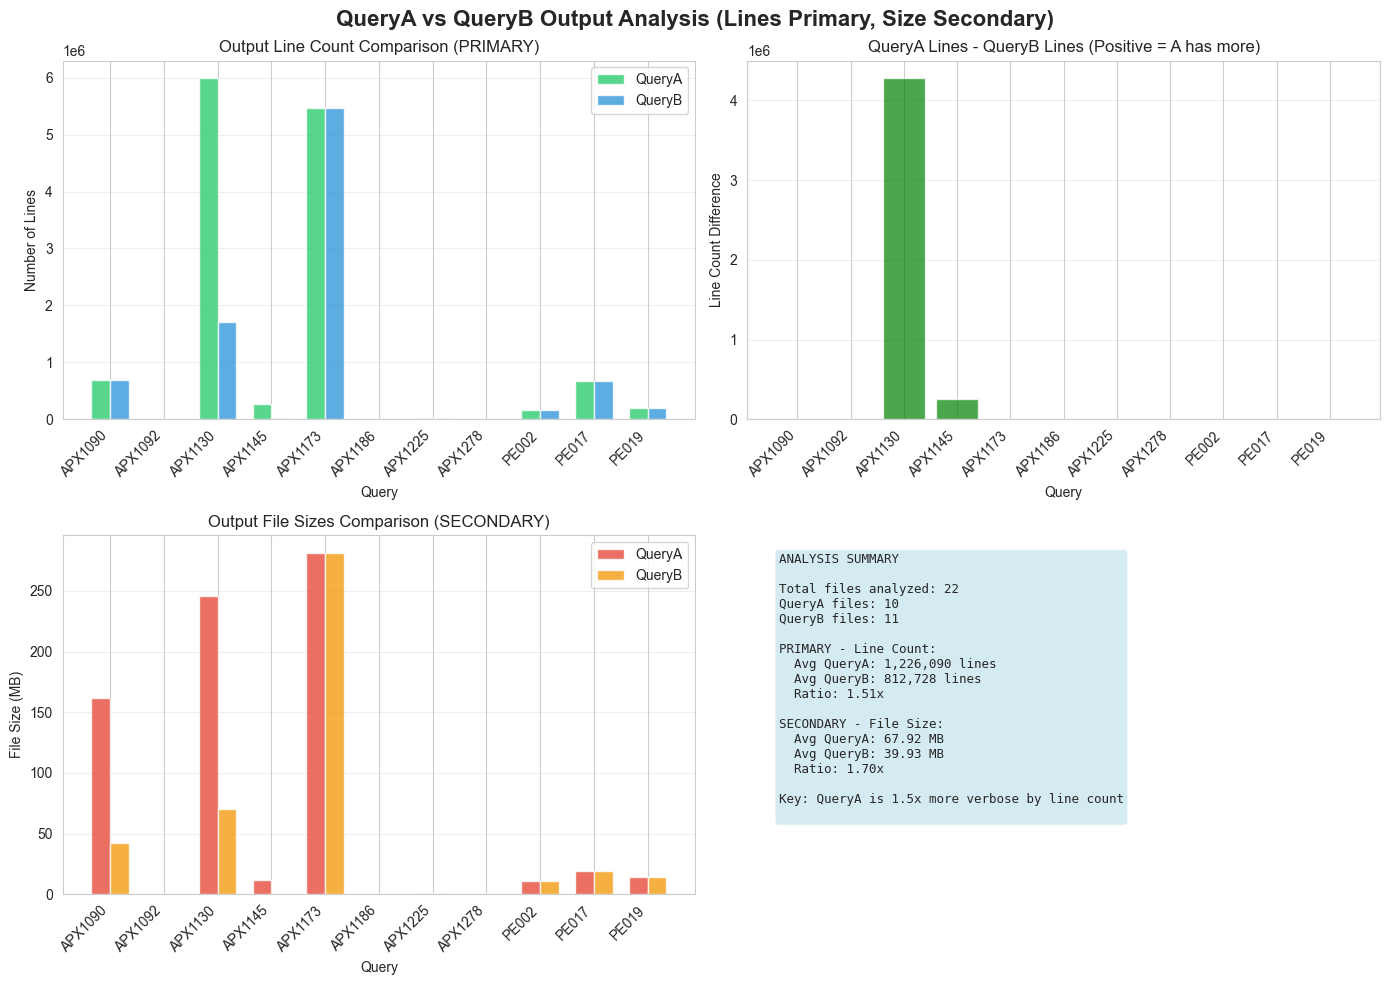


Visualization complete!


In [7]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('QueryA vs QueryB Output Analysis (Lines Primary, Size Secondary)', fontsize=16, fontweight='bold')

# 1. Line count comparison (PRIMARY)
ax1 = axes[0, 0]
if not detailed_df.empty:
    x = np.arange(len(detailed_df))
    width = 0.35
    ax1.bar(x - width/2, detailed_df['QueryA Lines'], width, label='QueryA', alpha=0.8, color='#2ecc71')
    ax1.bar(x + width/2, detailed_df['QueryB Lines'], width, label='QueryB', alpha=0.8, color='#3498db')
    ax1.set_xlabel('Query')
    ax1.set_ylabel('Number of Lines')
    ax1.set_title('Output Line Count Comparison (PRIMARY)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(detailed_df['Query'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

# 2. Line count difference distribution (PRIMARY)
ax2 = axes[0, 1]
line_diffs = detailed_df['Lines Diff'].values
colors = ['green' if x > 0 else 'red' for x in line_diffs]
ax2.bar(detailed_df['Query'], line_diffs, color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Query')
ax2.set_ylabel('Line Count Difference')
ax2.set_title('QueryA Lines - QueryB Lines (Positive = A has more)')
ax2.set_xticklabels(detailed_df['Query'], rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# 3. File size comparison (SECONDARY)
ax3 = axes[1, 0]
if not detailed_df.empty:
    x = np.arange(len(detailed_df))
    width = 0.35
    ax3.bar(x - width/2, detailed_df['QueryA Size (MB)'], width, label='QueryA', alpha=0.8, color='#e74c3c')
    ax3.bar(x + width/2, detailed_df['QueryB Size (MB)'], width, label='QueryB', alpha=0.8, color='#f39c12')
    ax3.set_xlabel('Query')
    ax3.set_ylabel('File Size (MB)')
    ax3.set_title('Output File Sizes Comparison (SECONDARY)')
    ax3.set_xticks(x)
    ax3.set_xticklabels(detailed_df['Query'], rotation=45, ha='right')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)

# 4. Analysis summary statistics
ax4 = axes[1, 1]
ax4.axis('off')
avg_lines_a = detailed_df['QueryA Lines'].mean()
avg_lines_b = detailed_df['QueryB Lines'].mean()
avg_size_a = detailed_df['QueryA Size (MB)'].mean()
avg_size_b = detailed_df['QueryB Size (MB)'].mean()
summary_text = f"""ANALYSIS SUMMARY

Total files analyzed: {len(output_files)}
QueryA files: {len(queryA_files)}
QueryB files: {len(queryB_files)}

PRIMARY - Line Count:
  Avg QueryA: {avg_lines_a:,.0f} lines
  Avg QueryB: {avg_lines_b:,.0f} lines
  Ratio: {(avg_lines_a/avg_lines_b):.2f}x

SECONDARY - File Size:
  Avg QueryA: {avg_size_a:.2f} MB
  Avg QueryB: {avg_size_b:.2f} MB
  Ratio: {(avg_size_a/avg_size_b):.2f}x

Key: QueryA is {(avg_lines_a/avg_lines_b):.1f}x more verbose by line count
"""
ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes, 
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

print("\nVisualization complete!")

## Appendix: Format Reference Guide

Quick reference for understanding the different output formats encountered.

### Standard QueryA Format
- Returns complete SQL result sets from queries
- PostgreSQL pipe-delimited tabular output format
- Includes headers and separator lines
- Example: `APX1090-queryA`, `APX1130-queryA`, etc.

### Standard QueryB Format
- Returns subset of columns from QueryA
- Same tabular format but fewer columns
- Typically much smaller file sizes
- Example: `APX1090-queryB`, `APX1130-queryB`, etc.

### Special APX1186-queryA Format ⚠️
- Uses NOTICE messages instead of standard output
- Each line contains: `Order: <number>, Price: <decimal>`
- Contains thousands of order/price pairs
- File size: ~473 KB (formatted differently than other queryA)
- Suggests special handling or debug output in this query

### Queries with Both A and B Variants
- APX1090, APX1092, APX1130, APX1145
- APX1173, APX1186, APX1225, APX1278
- PE002, PE017, PE019

### File Naming Convention
Pattern: `<UUID>__<QUERY-NAME>.sql__1_1.out`
- UUID: Unique run identifier
- QUERY-NAME: Query identifier (e.g., APX1090-queryA)
- 1_1: Batch/chunk identifiers